# Homework 1: sequence classification

In [1]:
import numpy as np
import re
import matplotlib.pyplot as plt
from Bio.Seq import Seq
from Bio.SeqUtils.ProtParam import ProteinAnalysis
from Bio.SeqUtils import ProtParamData # contains the scales

In [34]:
mioglobin = Seq('MGLSDGEWQLVLNVWGKVEADIPGHGQEVLIRLFKGHPETLEKFDKFKHLKSEDEMKASEDLKKHGATVLTALGGILKKKGHHEAEIKPLAQSHATKHKIPVKYLEFISECIIQVLQSKHPGDFGADAQGAMNKALELFRKDMASNYKELGFQG')
mastermind = Seq('MDDWKSRLVIKSMLPHFAMVGNRQEPRKLQESGKKPSWMEEEDLSFLYKSSPGRKHQGTVKRRQEEDHFQFPDMADGGYPNKIKRPCLEDVTLAMGPGAHPSTACAELQVPPLTINPSPAAMGVAGQSLLLENNPMNGNIMGSPFVVPQTTEVGLKGPTVPYYEKINSVPAVDQELQELLEELTKIQDPSPNELDLEKILGTKPEEPLVLDHPQATLSTTPKPSVQMSHLESLASSKEFASSCSQVTGMSLQIPSSSTGISYSIPSTSKQIVSPSSSMAQSKSQVQAMLPVALPPLPVPQWHHAHQLKALAASKQGSATKQQGPTPSWSGLPPPGLSPPYRPVPSPHPPPLPLPPPPPPFSPQSLMVSCMSSNTLSGSTLRGSPNALLSSMTSSSNAALGPAMPYAPEKLPSPALTQQPQFGPQSSILANLMSSTIKTPQGHLMSALPASNPGPSPPYRPEKLSSPGLPQQSFTPQCSLIRSLTPTSNLLSQQQQQQQQQQQANVIFKPISSNSSKTLSMIMQQGMASSSPGATEPFTFGNTKPLSHFVSEPGPQKMPSMPTTSRQPSLLHYLQQPTPTQASSATASSTATATLQLQQQQQQQQQQPDHSSFLLQQMMQQPQRFQRSVASDSMPALPRQGCCHLFAWTSAASSVKPQHQHGNSFTSRQDPQPGDVSPSNITHVDKACKLGEARHPQVSLGRQPPSCQALGSESFLPGSSFAHELARVTSSYSTSEAAPWGSWDPKAWRQVPAPLLPSCDATARGTEIRSYGNDP')
fus = Seq('MASNDYTQQATQSYGAYPTQPGQGYSQQSSQPYGQQSYSGYSQSTDTSGYGQSSYSSYGQSQNTGYGTQSTPQGYGSTGGYGSSQSSQSSYGQQSSYPGYGQQPAPSSTSGSYGSSSQSSSYGQPQSGSYSQQPSYGGQQQSYGQQQSYNPPQGYGQQNQYNSSSGGGGGGGGGGNYGQDQSSMSSGGGSGGGYGNQDQSGGGGSGGYGQQDRGGRGRGGSGGGGGGGGGGYNRSSGGYEPRGRGGGRGGRGGMGGSDRGGFNKFGGPRDQGSRHDSEQDNSDNNTIFVQGLGENVTIESVADYFKQIGIIKTNKKTGQPMINLYTDRETGKLKGEATVSFDDPPSAKAAIDWFDGKEFSGNPIKVSFATRRADFNRGGGNGRGGRGRGGPMGRGGYGGGGSGGGGRGGFPSGGGGGGGQQRAGDWKCPNPTCENMNFSWRNECNQCKAPKPDGPGGGPGGSHMGGNYGDDRRGGRGGYDRGGYRGRGGDRGGFRGGRGGGDRGGFGPGKMDSRGEHRQDRRERPY')
query_t = Seq('MNLLLILTFVAAAVAAPFDDDDKIVGGYICEENSVPYQVSLNSGYHFCGGSLISEQWVVSAGHCYKSRIQVRLGEHNIEVLEGNEQFINAAKIIRHPKYNSRTLDNDILLIKLSSPAVINSRVSAISLPTAPPAAGTESLISGWGNTLSSGADYPDELQCLDAPVLSQAECEASYPGKITNNMFCVGFLEGGKDSCQGDSGGPVVSNGELQGIVSWGYGCAQKNRPGVYTKVYNYVDWIKDTIAANS')
query_s = Seq('MDVFMKGLSKAKEGVVAAAEKTKQGVAEAAGKTKEGVLYVGSKTKEGVVHGVATVAEKTKEQVTNVGGAVVTGVTAVAQKTVEGAGSIAAATGFVKKDQLGKNEEGAPQEGILEDMPVDPDNEAYEMPSEEGYQDYEPEA')
query_m = Seq('MAEPRQEFEVMEDHAGTYGLGDRKDQGGYTMHQDQEGDTDAGLKESPLQTPTEDGSEEPGSETSDAKSTPTAEDVTAPLVDEGAPGKQAAAQPHTEIPEGTTAEEAGIGDTPSLEDEAAGHVTQARMVSKSKDGTGSDDKKAKGADGKTKIATPRGAAPPGQKGQANATRIPAKTPPAPKTPPSSGEPPKSGDRSGYSSPGSPGTPGSRSRTPSLPTPPTREPKKVAVVRTPPKSPSSAKSRLQTAPVPMPDLKNVKSKIGSTENLKHQPGGGKVQIINKKLDLSNVQSKCGSKDNIKHVPGGGSVQIVYKPVDLSKVTSKCGSLGNIHHKPGGGQVEVKSEKLDFKDRVQSKIGSLDNITHVPGGGNKKIETHKLTFRENAKAKTDHGAEIVYKSPVVSGDTSPRHLSNVSSTGSIDMVDSPQLATLADEVSASLAKQGL')
query_a = Seq('MELDHRTSGGLHAYPGPRGGQVAKPNVILQIGKCRAEMLEHVRRTHRHLLAEVSKQVERELKGLHRSVGKLESNLDGYVPTSDSQRWKKSIKACLCRCQETIANLERWVKREMHVWREVFYRLERWADRLESTGGKYPVGSESARHTVSVGVGGPESYCHEADGYDYTVSPYAITPPPAAGELPGQEPAEAQQYQPWVPGEDGQPSPGVDTQIFEDPREFLSHLEEYLRQVGGSEEYWLSQIQNHMNGPAKKWWEFKQGSVKNWVEFKKEFLQYSEGTLSREAIQRELDLPQKQGEPLDQFLWRKRDLYQTLYVDADEEEIIQYVVGTLQPKLKRFLRHPLPKTLEQLIQRGMEVQDDLEQAAEPAGPHLPVEDEAETLTPAPNSESVASDRTQPE')


seq_dict = {
    "mioglobin": mioglobin,
    "mastermind": mastermind,
    "fus": fus,
    "query_t": query_t,
    "query_s": query_s,
    "query_m": query_m,
    "query_a": query_a
}

Observations (visual reading, no computation yet): 

- **QUERY_T** appears to contain many different letters and few repetitions (high entropy = high information = high complexity). I expect a quite ordered structure (e.g. helices). Also there are $C$ residues in various points inside the structure. These form disulfide bridges so I expect that they stabilize the structure. 

- **QUERY_S**: more repetitions (e.g. AAA, KK, EE, VV) and fewer letters represented. Many *non* polar aminoacids. Maybe the protein will be compact, but not in an ordered way.

- **QUERY_M**: : there are some repetitions (KK, 
SS, PP). There is a lot of Proline P with respect to the other sequences. Proline adds rigidity, so... ? 

- **QUERY_A**: I dont know honestly.... A lot of Q (some QQ too)... Some WW,,KK...

# Shannon Entropy

In [ ]:
def shannon_entropy(sequence:np.array):
    n = len(sequence)
    _, counts = np.unique(sequence, return_counts = True)
    return - np.sum(np.log2(counts/n) * (counts/n))



def sliding_window_entropy(sequence, window_length=21):
    sequence = np.array(list(sequence))
    n = len(sequence)
    
    # A true sliding window has (n - window + 1) positions
    n_results = n - window_length + 1
    results = np.zeros(n_results)
    indices = np.arange(n_results)
    
    for i in range(n_results):
        window_slice = sequence[i : i + window_length]
        results[i] = shannon_entropy(window_slice)
        
    return indices, results



def kl_divergence(sequence_a, sequence_b):

    analysis_a = ProteinAnalysis(sequence_a)
    analysis_b = ProteinAnalysis(sequence_b)
    p_dict = analysis_a.amino_acids_percent
    q_dict = analysis_b.amino_acids_percent
    
    epsilon = 1e-10
    
    amino_acids = "ACDEFGHIKLMNPQRSTVWY"
    P = np.array([p_dict.get(aa, 0) for aa in amino_acids]) + epsilon
    Q = np.array([q_dict.get(aa, 0) / 100 for aa in amino_acids]) + epsilon
    
    P /= P.sum()
    Q /= Q.sum()
    
    kl_div = np.sum(P * np.log2(P / Q))
    
    return kl_div




In [4]:
H_mioglobin = sliding_window_entropy(np.array(list(mioglobin)))
H_mastermind = sliding_window_entropy(np.array(list(mastermind)))
H_fus = sliding_window_entropy(np.array(list(fus)))


H_t = sliding_window_entropy(np.array(list(query_t)))
H_s = sliding_window_entropy(np.array(list(query_s)))
H_m = sliding_window_entropy(np.array(list(query_m)))
H_a = sliding_window_entropy(np.array(list(query_a)))

Text(0.5, 1.05, 'Shannon Entropy (21 residues sliding window)')

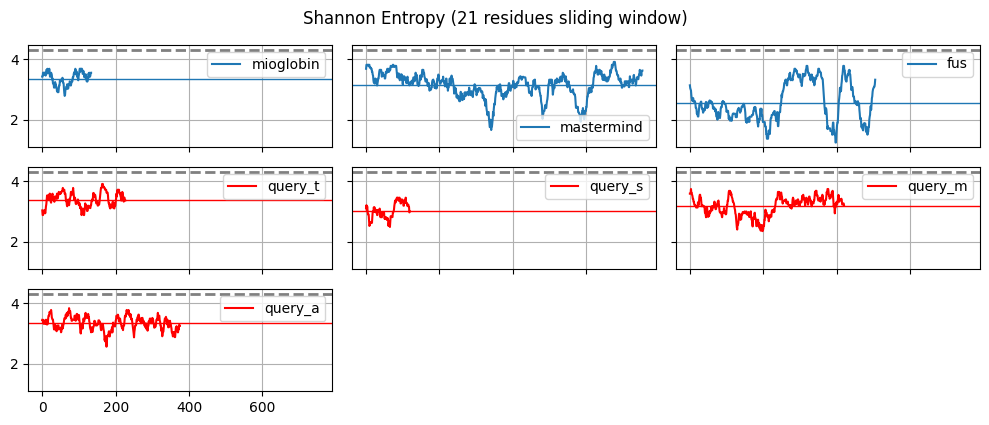

In [5]:
fig, axs = plt.subplots(nrows = 3, ncols = 3, sharex = True, sharey = True, figsize = (10, 4))
axs = axs.flatten()
axs[0].plot(H_mioglobin[0], H_mioglobin[1], label = "mioglobin")
axs[0].axhline(np.mean(H_mioglobin[1]), linewidth = 1)
axs[1].plot(H_mastermind[0], H_mastermind[1], label = "mastermind")
axs[1].axhline(np.mean(H_mastermind[1]), linewidth = 1)
axs[2].plot(H_fus[0], H_fus[1], label = "fus")
axs[2].axhline(np.mean(H_fus[1]), linewidth = 1)
axs[3].plot(H_t[0], H_t[1], label = "query_t", color = "red")
axs[3].axhline(np.mean(H_t[1]), linewidth = 1, color = "red")
axs[4].plot(H_s[0], H_s[1], label = "query_s", color = "red")
axs[4].axhline(np.mean(H_s[1]), linewidth = 1, color = "red")
axs[5].plot(H_m[0], H_m[1], label = "query_m", color = "red")
axs[5].axhline(np.mean(H_m[1]), linewidth = 1, color = "red")
axs[6].plot(H_a[0], H_a[1], label = "query_a", color = "red")
axs[6].axhline(np.mean(H_a[1]), linewidth = 1, color = "red")
axs[7].axis("off")
axs[8].axis("off")

for ax in axs[:7]:
    ax.grid()
    ax.legend()
    ax.axhline(y = np.log2(20), linewidth = 2, linestyle = "dashed" , color = "grey", label = "max entropy")
plt.tight_layout()
plt.suptitle("Shannon Entropy (21 residues sliding window)", y = 1.05)

Observations:

- the mastermind and the fus, which - as I know already - are disordered proteins, show regions with *low* Shannon entropy.
- hemoglobin, on the other hand, keeps a fairly high shannon entropy throughout. 

As for the four unkown structures:

- query_t and query_a: have a relatively high shannon entropy. I expect it may be similar to hemoglobin.
- query_s and query_m have lower average entropy.

While my reference sequences mastermind and fus show an alternation of high entropy and low entropy regions, with high amplitude of fluctuations, for these unknown proteins, the entropy fluctuates less widely around its average.

# Cross Entropy (KL divergence)

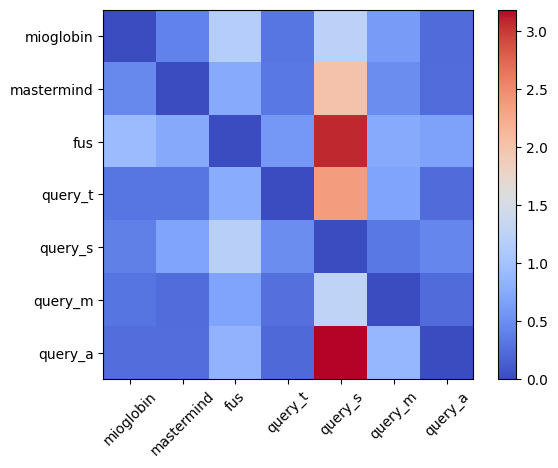

In [45]:
kl_matrix = np.zeros((7, 7))

for i, name_a in enumerate(seq_dict.keys()):
    for j, name_b in enumerate(seq_dict.keys()):
        kl_matrix[i, j] = kl_divergence(seq_dict[name_a], seq_dict[name_b])


im = plt.imshow(kl_matrix, cmap = "coolwarm")
names =seq_dict.keys()
plt.xticks(range(len(names)), names, rotation = 45)
plt.yticks(range(len(names)), names)
plt.colorbar(im)
plt.show()

query_s is anomalous: it does not resemble closely any of the three reference sequences.

# Motifs detection

In [6]:
def count_repetitions(seq):
    seq = str(seq)
    matches = [m.group(0) for m in re.finditer(r'(.)\1+', seq)]
    return len(matches), matches

print(f"{'Sequence':<12} | {'Entropy':<5} | {'Count/Length':<8} | {'Repetitions Found':<15}|")
print("-" * 90)




for name, seq in seq_dict.items():
    entropy = shannon_entropy(np.array(list(seq)))
    count, reps = count_repetitions(seq)
    ratio = np.sum([len(rep) for rep in reps]) / len(seq)
    unique_reps = sorted(np.unique(reps), key=len, reverse=True)
    
    reps_str = ", ".join(unique_reps)
    print(f"{name:<12} |{entropy:<5.4f} | {ratio:<8.3f} | {reps_str}")


print(f"Maximum reacheable entropy (20 amino-acids): {np.log2(20):.4f}")

Sequence     | Entropy | Count/Length | Repetitions Found|
------------------------------------------------------------------------------------------
mioglobin    |3.9918 | 0.071    | KKK, GG, HH, II, KK
mastermind   |3.9573 | 0.208    | QQQQQQQQQQQ, QQQQQQQQQQ, PPPPPP, EEE, LLL, PPP, SSS, AA, CC, DD, EE, GG, HH, KK, LL, MM, NN, PP, QQ, RR, SS, TT, VV, YY
fus          |3.5224 | 0.346    | GGGGGGGGGG, GGGGGGG, GGGG, GGG, QQQ, SSS, AA, DD, GG, II, KK, NN, PP, QQ, RR, SS
query_t      |4.1072 | 0.178    | DDDD, AAA, LLL, AA, EE, GG, II, LL, NN, PP, SS, VV
query_s      |3.6525 | 0.157    | AAA, AA, EE, GG, KK, VV
query_m      |3.9190 | 0.147    | AAA, GGG, AA, DD, EE, GG, HH, II, KK, PP, SS, TT, VV
query_a      |4.1072 | 0.111    | EEE, PPP, AA, DD, EE, GG, II, KK, LL, QQ, RR, VV, WW
Maximum reacheable entropy (20 amino-acids): 4.3219


- mioglobin: repetitions of long charged aminoacids (lysine K, histidine H) and of glicine G
- mastermind: huge repetitions of the polar glutamine (Q), charged glutamic acid (E), rigid proline (P), and many others
- fus: huge repetitions of glicine G, polar glutamine Q, serine S


- query_t: charged aspartic acid (D), lysine L and glutamic acid (E).
- query_s: repetitions of the small, non polar alanine A and glicine G and valine V, then glutaminc acid E and glutamine G, charged lisine K.

- query_m : EE, GG, HH
- query_a: EEE, QQ, WW

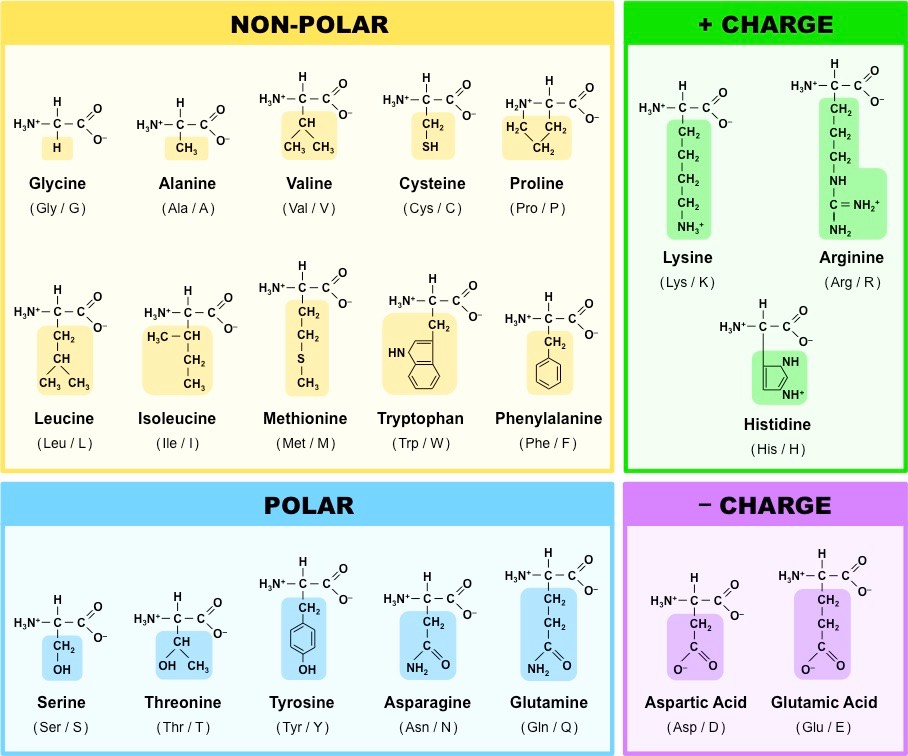

In [7]:
from IPython import display

# Usage examples:
display.Image(filename='amino-acid_table.jpeg', width = 500)

# Composition Analysis

**Average composition of human proteome**

UniProt: amino-acid composition (Reviewed: Swiss Prot)

https://www.uniprot.org/proteomes/UP000005640

Proteome (Human)

FASTA file: one protein sequence per gene.

In [8]:
from Bio import SeqIO
from collections import Counter

def get_human_proteome_composition(fasta_file):
    total_counts = Counter()
    total_amino_acids = 0
    for record in SeqIO.parse(fasta_file, "fasta"):
        clean_seq = [aa for aa in str(record.seq) if aa in "ACDEFGHIKLMNPQRSTVWY"]
        total_counts.update(clean_seq)
        total_amino_acids += len(clean_seq)
    composition = {aa: (count / total_amino_acids) * 100 for aa, count in total_counts.items()}
    return dict(sorted(composition.items()))

human_averages = get_human_proteome_composition("UP000005640_9606.fasta")

aa_groups = {
    'L': 'grey', 'A': 'grey', 'G': 'grey', 'V': 'grey', 'I': 'grey', 'P': 'grey', # Aliphatic
    'E': 'red', 'D': 'red',                                                       # Acidic (donate H+ -> become negative charged)
    'S': 'forestgreen', 'T': 'forestgreen',                                       # Small Hydrox
    'R': 'blue', 'K': 'blue', 'H': 'blue',                                        # Basic (accept H+ -> becomepositive charged)
    'F': 'black', 'Y': 'black', 'W': 'black',                                     # Aromatic
    'Q': 'white', 'N': 'white',                                                   # Amide
    'M': 'yellow', 'C': 'yellow'                                                  # Sulfur
}


from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='grey', edgecolor='black', label='aliphatic. low polarity'),
    Patch(facecolor='red', edgecolor='black', label='acidic (donate H+ -> become negative charged). high polarity'),
    Patch(facecolor='forestgreen', edgecolor='black', label='small hydrox (medium polarity, signal transmitters)'),
    Patch(facecolor='blue', edgecolor='black', label='basic (donate H+ -> become negative charged). high polarity'),
    Patch(facecolor='black', edgecolor='black', label='aromatic. Bulky, hydrophopic, FORM CONDENSATES'),
    Patch(facecolor='white', edgecolor='black', label='amide (NH2 group) -medium polarity, both H+ donors and acceptors, signal transmitters, FORM AMYLOIDS'),
    Patch(facecolor='yellow', edgecolor='black', label='sulfur - form SS bonds'),
]

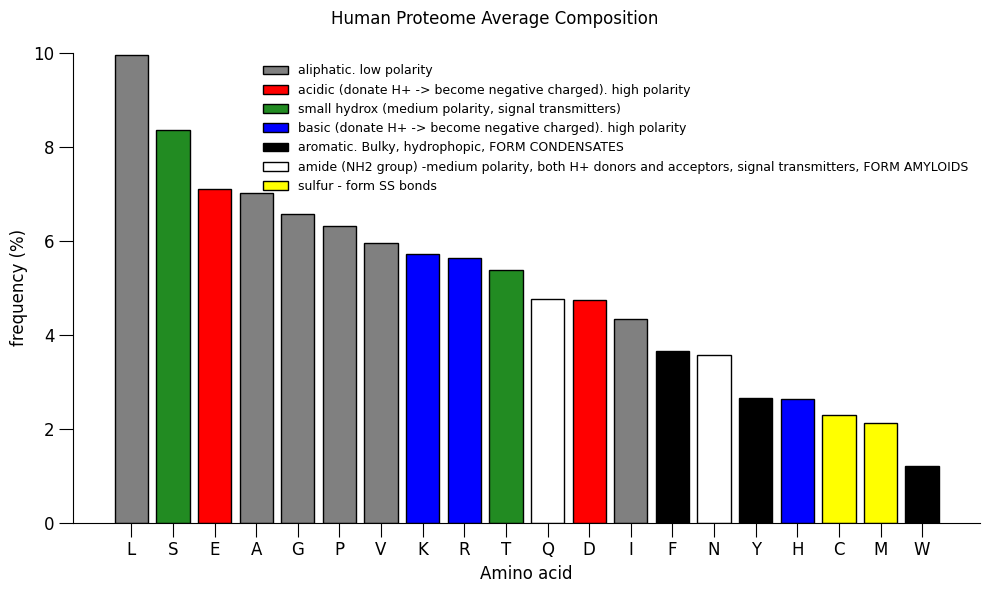

In [9]:
sorted_data = sorted(human_averages.items(), key=lambda x: x[1], reverse=True)
labels = [x[0] for x in sorted_data]
values = [x[1] for x in sorted_data]
colors = [aa_groups[x[0]] for x in sorted_data]


fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(labels, values, color=colors, edgecolor='black', linewidth=1)

ax.set_ylabel('frequency (%)', fontsize=12)
ax.set_xlabel('Amino acid', fontsize=12)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', which='major', labelsize=12, length=10)
ax.set_ylim(0, 10) 


ax.legend(handles=legend_elements, fontsize=9, frameon=False, loc='upper right')

plt.suptitle("Human Proteome Average Composition")
plt.tight_layout()
plt.show()

In [10]:
def compare_compositions(seq, human_ref):
    analysis_object = ProteinAnalysis(str(seq))
    query_comp = analysis_object.amino_acids_percent
    differences = {}
    for aa in "ACDEFGHIKLMNPQRSTVWY":
        q_perc = query_comp.get(aa, 0)
        h_perc = human_ref.get(aa, 0)
        differences[aa] = q_perc - h_perc
    return differences


def plot_difference_composition(ax, sequence, human_averages, legend = False, title = None):
    # Grouping logic
    aa_groups = {
        'L': 'grey', 'A': 'grey', 'G': 'grey', 'V': 'grey', 'I': 'grey', 'P': 'grey', # Aliphatic
        'E': 'red', 'D': 'red',                                                       # Acidic
        'S': 'forestgreen', 'T': 'forestgreen',                                       # Small Hydrox
        'R': 'blue', 'K': 'blue', 'H': 'blue',                                        # Basic
        'F': 'black', 'Y': 'black', 'W': 'black',                                     # Aromatic
        'Q': 'white', 'N': 'white',                                                   # Amide
        'M': 'yellow', 'C': 'yellow'                                                  # Sulfur
    }
    diffs = compare_compositions(sequence, human_averages)

    sorted_data = sorted(diffs.items(), key=lambda x: x[1], reverse=True)
    labels = [x[0] for x in sorted_data]
    values = [x[1] for x in sorted_data]
    colors = [aa_groups[x[0]] for x in sorted_data]

    ax.bar(labels, values, color=colors, edgecolor='black', linewidth=1)
    ax.set_ylabel('frequency (%)', fontsize=12)
    ax.set_xlabel('Amino acid', fontsize=12)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='both', which='major', labelsize=12, length=10)
    ax.set_ylim(-10, 10) 
    ax.set_xlabel("")
    if legend:
        ax.legend(handles=legend_elements, fontsize=10, frameon=False, loc='upper right')
    if title is not None:
        ax.set_title(title)

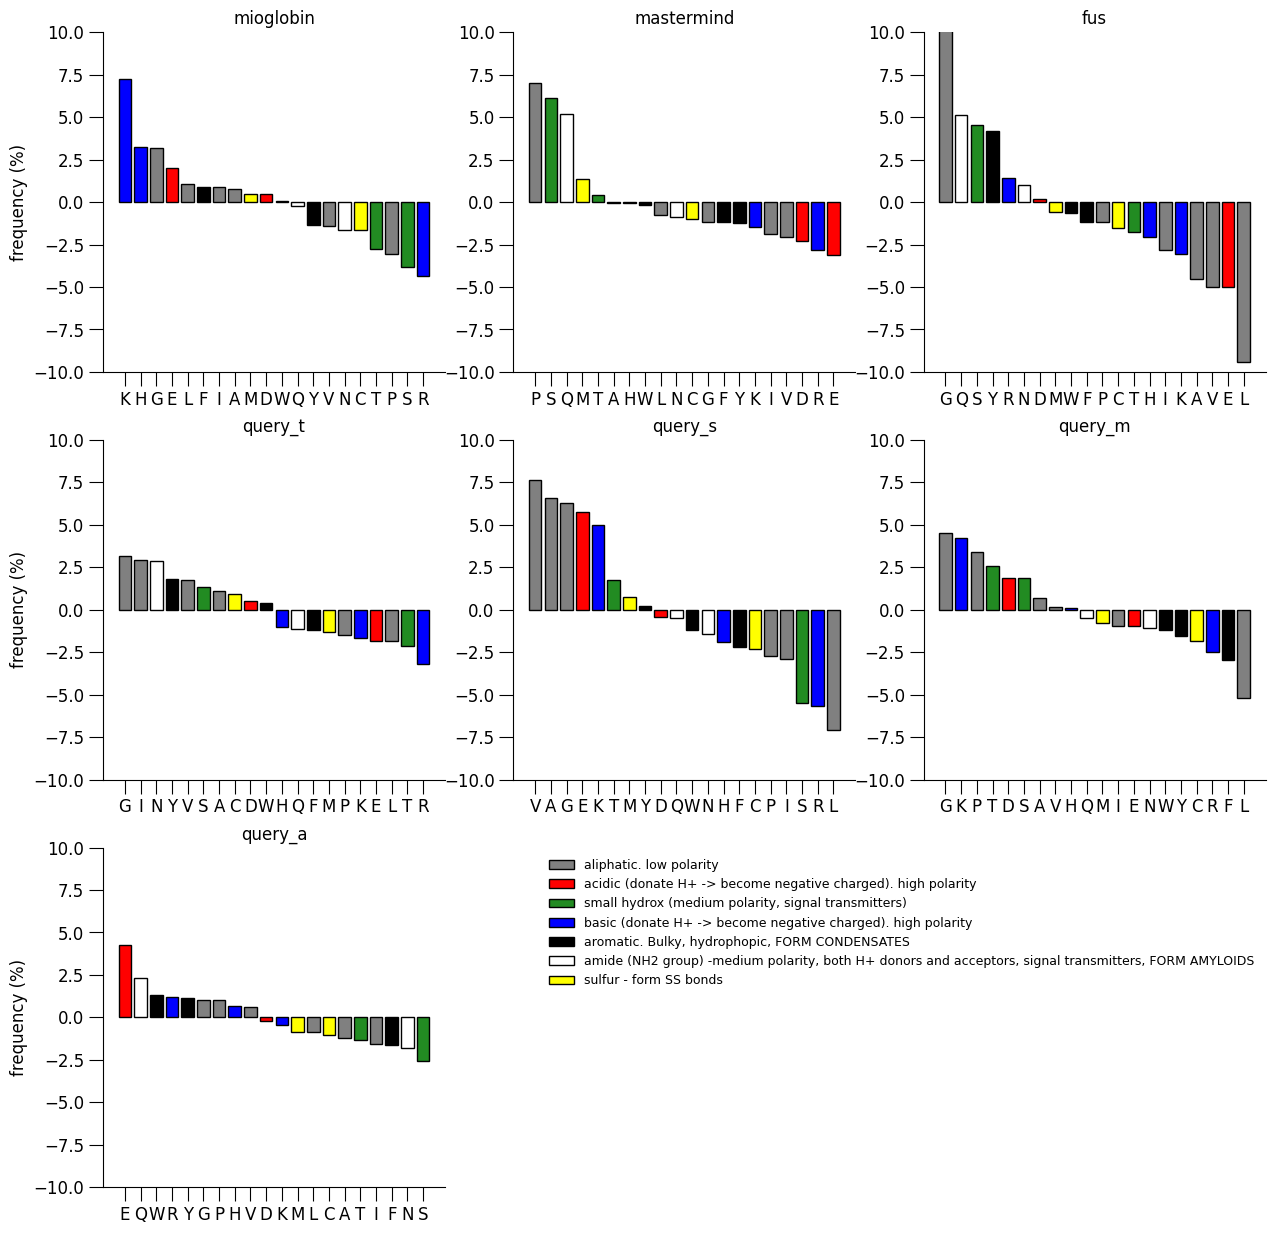

In [11]:
fig, axs = plt.subplots(3,3, figsize = (15, 15))

axs = axs.flatten()

for i, seq in enumerate(seq_dict.keys()):
    plot_difference_composition(axs[i], seq_dict[seq], human_averages, legend = False, title = seq)


for i, ax in enumerate(axs):
    if i% 3 != 0:
        ax.set_ylabel("")

axs[8].legend(handles=legend_elements, fontsize=9, frameon=False, loc='upper right')

axs[7].axis("off")
axs[8].axis("off")
plt.show()


- aliphatic: non cyclic
- amide: Glutamine (Q) and Asparagine (N). Amino-acids with an amine group (NH2) in the residue. They are ploar. 
- sulfur: cysteine C and methilionine M. They form SS bonds.

Analysis:


- **query_t and query_a** revealed a fairly high shannon entropy in the previous analyiisis. here, they reveal a composition that does not deviate much from the average human proteome composition. This doesnt imply automatically that they are ordered. Mioglobin, for instance, is highly ordered even though it has a composition that deviates quite strongly form the proteome average. For the moment, lets just say that these two proteins do not look "special".

- **query_s and query_m**, i.e. the proteins with lower shannon entropy, also exibit larger differences in composition with respect to the average.
    Lets look for **disorder-promoting** residues.



**Disorder Promoting residues:**

- Proline P: the helix breaker, it cannot fit into standard helices or beta sheets because of its rigidity
- Glycine G: because is very flexible 
- Charged

**Order promoting residues:**

- the big non polars, especially  Leucine is branched and hydrophopic. It is important in the formation of the hydrophobic core.
     Being branched, it occupies more space, hence allowing for more water molecules to be released from the protein core.
- the bulky (aromatics, V, I)



**our queries:**

- Mastermind: lots of proline P (helix breaker), lots of Q (polar), lots of serine S (small, flexible).
- Fus: lots of glycine G and serine S (small, flexible), lots of Q and Y (polar). Significantly depleted in leucine L.
- **query_s**: lots of small, flexible G, and A. Lots of charged, polar E and K. Depleated in leucine L.
- **query_m**: significantly depelated in leucine L. Enriched in proline P.




From this analysis, my suspect grows stronger that **query_s** and **query_m** could be DISORDERED PROTEINS.

# Hydrophaty scale

Wiki: https://en.wikipedia.org/wiki/Hydrophilicity_plot

KYTE-DOOLITTLE SCALE

more positive value = more hydrophobic

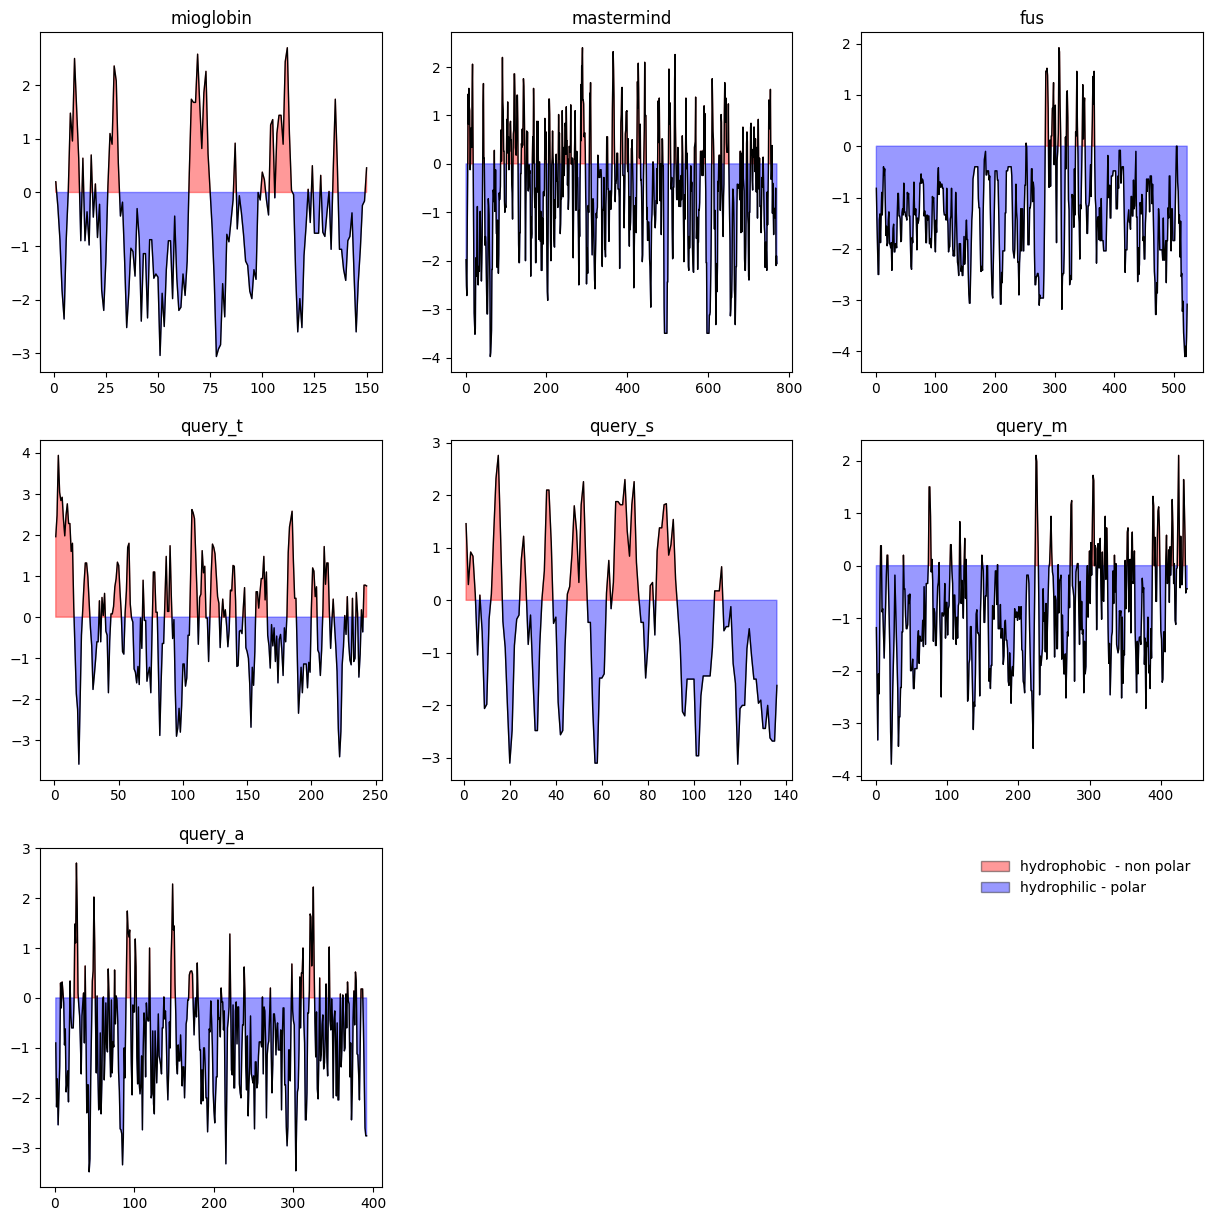

In [27]:
fig, axs = plt.subplots(3,3, figsize = (15, 15))

axs = axs.flatten()

for i, seq in enumerate(seq_dict.keys()):
    sequence = seq_dict[seq]
    analysis_object = ProteinAnalysis(str(sequence))
    hp_vals = analysis_object.protein_scale(param_dict = ProtParamData.kd, window = 5)     # ProtParamData.kd # hydrophaty scale
    hp_vals = np.array(hp_vals)
    x = np.arange(1, len(hp_vals) + 1)

    ax = axs[i]

    ax.set_title(seq)
    ax.fill_between(x, hp_vals, 0, where=(hp_vals >= 0), color='red', alpha=0.4, interpolate=True)
    ax.fill_between(x, hp_vals, 0, where=(hp_vals < 0), color='blue', alpha=0.4, interpolate=True)
    ax.plot(x, hp_vals, color='black', linewidth=1)



legend_elements = [
    Patch(facecolor='red', alpha = 0.4,  edgecolor='black', label='hydrophobic  - non polar'),
    Patch(facecolor='blue', alpha = 0.4, edgecolor='black', label='hydrophilic - polar')
]

axs[8].axis("off")
axs[7].axis("off")
axs[8].legend(handles=legend_elements, fontsize=10, frameon=False, loc='upper right')

Based on *this* other analysis, I can:

- confirm the similarity of query_t to hemoglobin: my belief that this structure is ordered gets reinforced.

- confirm the similiarity of query_m to fus: my believe that this sturcture is disordered gets reinforced too.


However, I have more doubts about query_s and query_a:

- query_s has a long region of polar residues at its end... maybe, this is an active site, or a "mechanical motor unit"?
- query_a, has hih entropy and a composition that odesnt differ much fron the proteome average, however its hydrophaty profile looks similar to that of mastermind. So maybe this is also disordered?

# FINAL GUESSES:


- **query_t** most likely has an ordered structure: it exibits high shannon entropy, normal composition and a balanced hydrophaty profile.

- **query_s** could be a protein with a relatively stable core and a loose polar tail that is responsible for some function. It does not resemble any of the three reference sequences. Not sure.

- **query_m** is most likely disordered, as it is rich in flexible and polar residues and depeated in leucine, and shows a hydropathy profile compatible with fus.

- **query_a** is likely disordered, as it is enriched in charged and aromatic residues and exibits a hydrophaty profile similar to mastermind. Not sure.

# ------------------------------------------------------------------------------

# Lets check with BLAST

https://blast.ncbi.nlm.nih.gov/smartblast/smartBlast.cgi


- **query_t**: trypsin-2 isoform 1 preproprotein [Homo sapiens]

    PDB: https://www.rcsb.org/structure/1BRC


    This sequence is Trypsin, specifically the anionic form. It is a proteolytic enzyme (a serine protease) produced in the pancreas.
    Guess was correct!


- **query_s**: alpha-synuclein [Rattus norvegicus]

    PDB: https://www.rcsb.org/structure/1XQ8 - Ordered helix with a loose tail at the end!! The guess was correct!
    It is an Intrinsically Disordered Protein (IDP). it is most famous for its role in Parkinson’s Disease, where it misfolds into "Lewy bodies" (solid aggregates).

- **query_m**: microtubule-associated protein tau isoform 5 [Homo sapiens]


    Tau is intrinsically disordered. It is very hydrophilic and enriched in Proline and Lysine. 
    Its job is to stabilize microtubules (the "railroad tracks") inside neurons. Has a role in Alzheimer’s Disease.


- **query_a**: activity-regulated cytoskeleton-associated protein [Pongo abelii]

    It acts as a "molecular switch" for the Rho family of GTPases. It helps turn OFF signals that control the cell's skeleton (actin cytoskeleton), cell movement, and cell division.


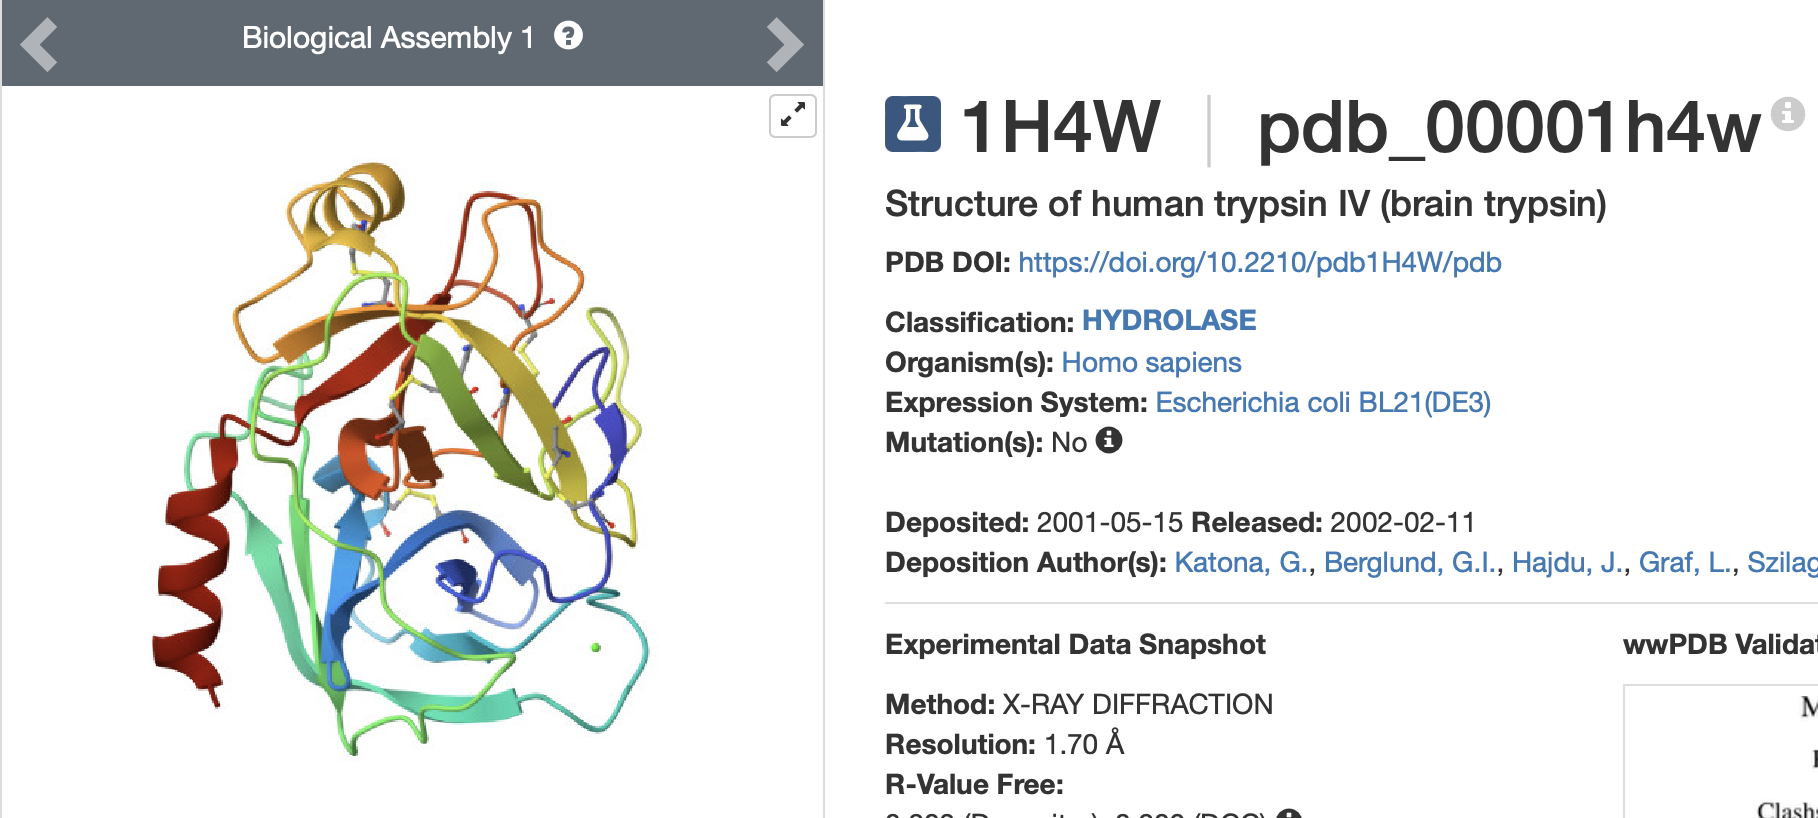

In [56]:
display.Image(filename='trypsine.png', width = 500)

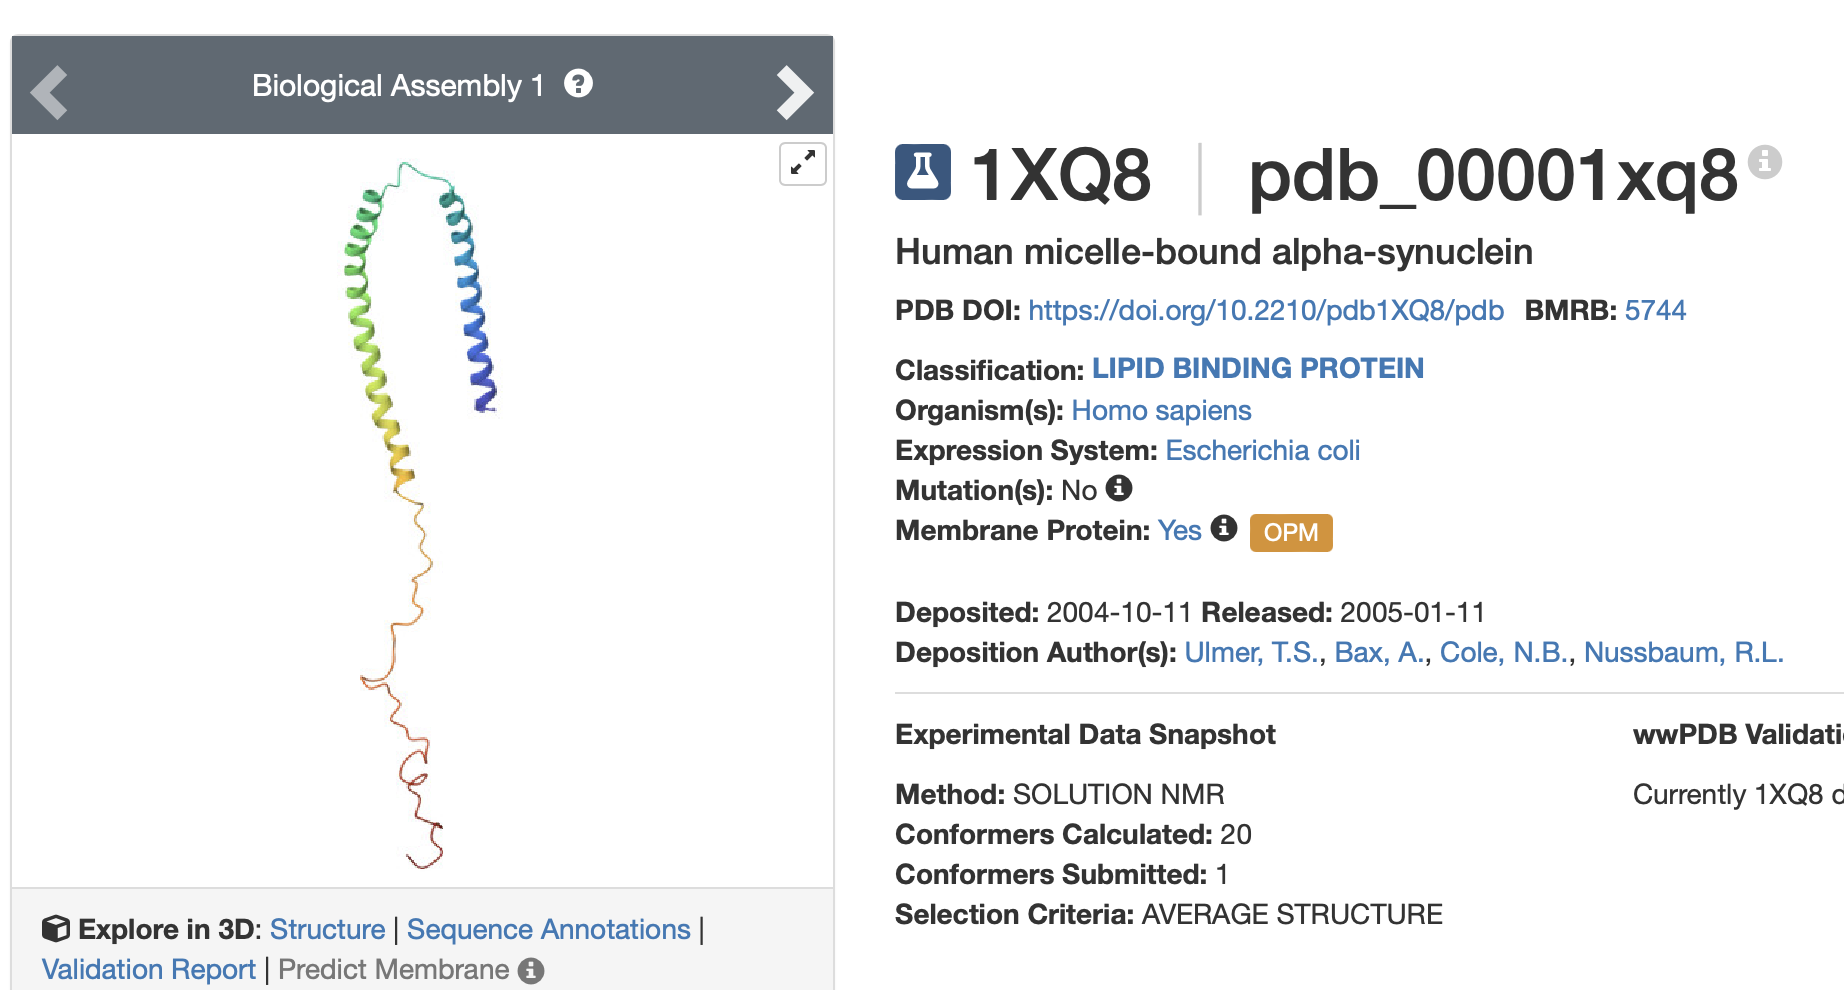

In [58]:
display.Image(filename='alpha_synuclein.png', width = 500)